In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROCESSED_DIR = Path("../data/processed")
arquivo = PROCESSED_DIR / "vagas_validadas.parquet"
if not arquivo.exists():
    arquivo = PROCESSED_DIR / "vagas_extraidas.parquet"
vagas = pd.read_parquet(arquivo)

AZUL = "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.titlecolor": "#0b0b0b",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "ytick.labelcolor": "#52514e",
    "figure.dpi": 110,
})


def barras_horizontais(series, titulo, xlabel, ax=None, cor=AZUL):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 0.42 * len(series) + 1))
    ordenada = series.sort_values()
    ax.barh(ordenada.index, ordenada * 100, color=cor, height=0.62)
    for i, v in enumerate(ordenada):
        ax.text(v * 100 + 0.8, i, f"{v:.0%}", va="center", color="#52514e", fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, ordenada.max() * 115)
    ax.grid(axis="y", visible=False)
    return ax


print(f"{len(vagas)} vagas carregadas de {arquivo.name}")

283 vagas carregadas de vagas_validadas.parquet


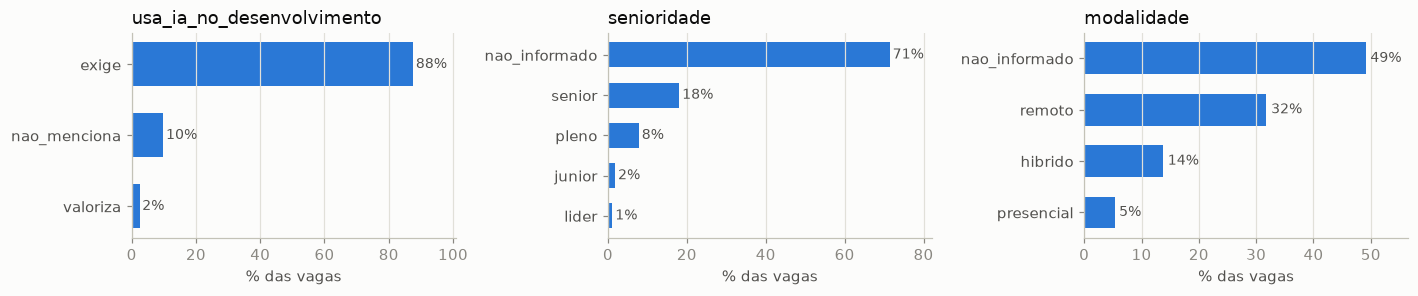

exige inglês: 34% · exige formação superior: 34%


In [2]:
fig, eixos = plt.subplots(1, 3, figsize=(13, 2.8))
for ax, campo in zip(eixos, ["usa_ia_no_desenvolvimento", "senioridade", "modalidade"]):
    barras_horizontais(vagas[campo].value_counts(normalize=True), campo, "% das vagas", ax=ax)
fig.tight_layout()
plt.show()

print(f"exige inglês: {vagas['exige_ingles'].mean():.0%} · "
      f"exige formação superior: {vagas['exige_formacao_superior'].mean():.0%}")

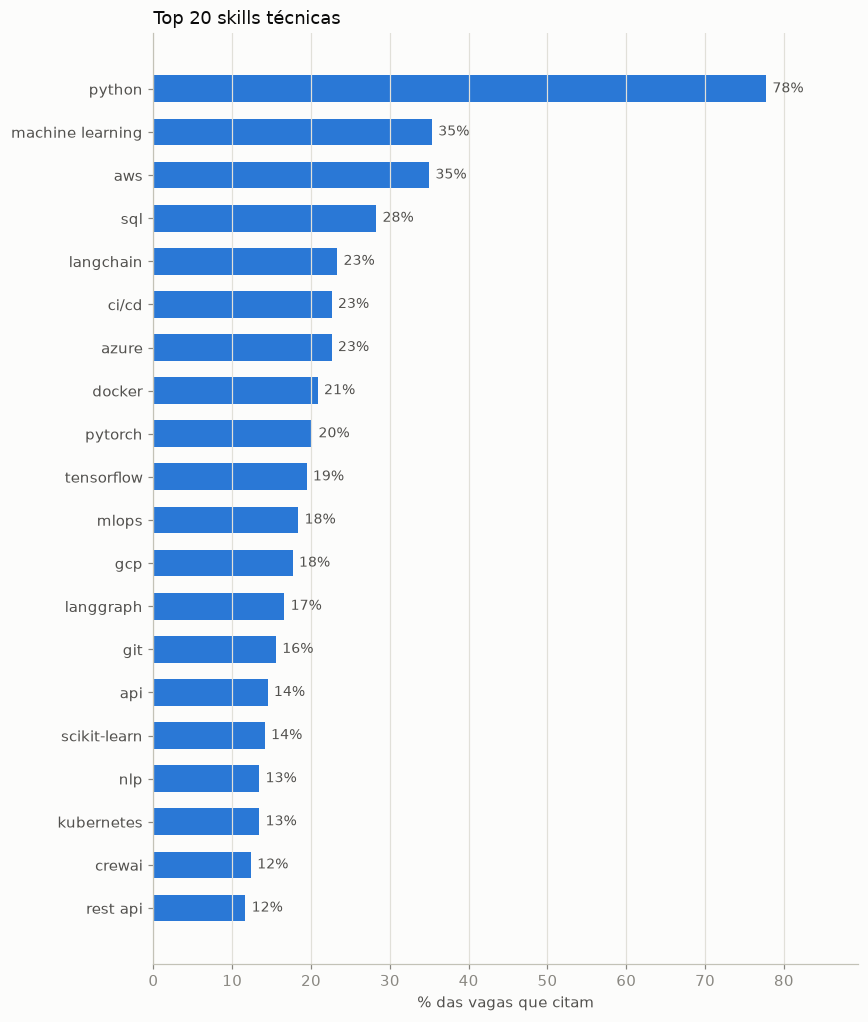

In [3]:
freq_skills = (
    vagas["skills_tecnicas"].explode().dropna()
    .groupby(level=0).unique().explode()
    .value_counts() / len(vagas)
)
barras_horizontais(freq_skills.head(20), "Top 20 skills técnicas", "% das vagas que citam")
plt.tight_layout()
plt.show()

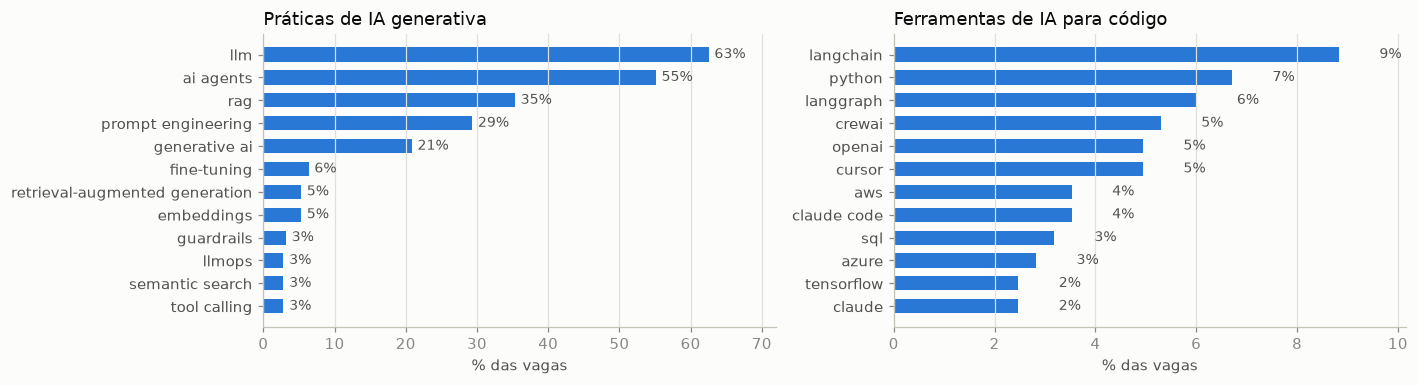

vagas com ao menos 1 prática GenAI: 78% · com ferramenta de IA p/ código nomeada: 30%


In [4]:
freq_praticas = (
    vagas["praticas_genai"].explode().dropna()
    .groupby(level=0).unique().explode()
    .value_counts() / len(vagas)
)
freq_ferramentas = (
    vagas["ferramentas_ia_codigo"].explode().dropna()
    .groupby(level=0).unique().explode()
    .value_counts() / len(vagas)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.6))
barras_horizontais(freq_praticas.head(12), "Práticas de IA generativa", "% das vagas", ax=ax1)
barras_horizontais(freq_ferramentas.head(12), "Ferramentas de IA para código", "% das vagas", ax=ax2)
fig.tight_layout()
plt.show()

com_pratica = vagas["praticas_genai"].str.len().gt(0).mean()
com_ferramenta = vagas["ferramentas_ia_codigo"].str.len().gt(0).mean()
print(f"vagas com ao menos 1 prática GenAI: {com_pratica:.0%} · "
      f"com ferramenta de IA p/ código nomeada: {com_ferramenta:.0%}")

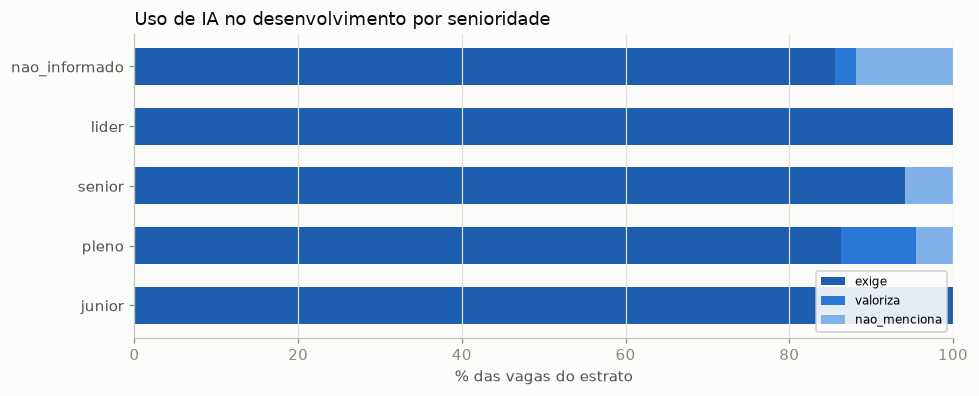

usa_ia_no_desenvolvimento,exige,nao_menciona,valoriza
senioridade,,,
junior,5,0,0
lider,3,0,0
nao_informado,173,24,5
pleno,19,1,2
senior,48,3,0


In [5]:
ordem_senioridade = ["estagio", "junior", "pleno", "senior", "lider", "nao_informado"]
ordem_uso = ["exige", "valoriza", "menciona", "nao_menciona"]

tabela = (
    pd.crosstab(vagas["senioridade"], vagas["usa_ia_no_desenvolvimento"], normalize="index")
    .reindex(index=[s for s in ordem_senioridade if s in vagas["senioridade"].unique()],
             columns=[u for u in ordem_uso if u in vagas["usa_ia_no_desenvolvimento"].unique()])
)

cores = ["#1d5fae", "#2a78d6", "#7fb0e8", "#d9d8d0"]
fig, ax = plt.subplots(figsize=(9, 0.5 * len(tabela) + 1.2))
esquerda = np.zeros(len(tabela))
for coluna, cor in zip(tabela.columns, cores):
    ax.barh(tabela.index, tabela[coluna] * 100, left=esquerda, color=cor,
            height=0.62, label=coluna)
    esquerda += tabela[coluna].to_numpy() * 100
ax.set_title("Uso de IA no desenvolvimento por senioridade")
ax.set_xlabel("% das vagas do estrato")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()

pd.crosstab(vagas["senioridade"], vagas["usa_ia_no_desenvolvimento"])

In [6]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

textos = (
    (vagas["skills_tecnicas"].map(list) + vagas["praticas_genai"].map(list))
    .map(lambda itens: ", ".join(itens) if len(itens) else "sem skills declaradas")
)
modelo_emb = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = modelo_emb.encode(textos.tolist(), show_progress_bar=True)

silhuetas = {}
for k in range(2, 9):
    rotulos = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(embeddings)
    silhuetas[k] = silhouette_score(embeddings, rotulos)

melhor_k = max(silhuetas, key=silhuetas.get)
print({k: round(s, 3) for k, s in silhuetas.items()})
print(f"melhor k pela silhueta: {melhor_k}")

vagas["cluster"] = KMeans(n_clusters=melhor_k, random_state=42, n_init=10).fit_predict(embeddings)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

{2: 0.119, 3: 0.114, 4: 0.123, 5: 0.113, 6: 0.077, 7: 0.078, 8: 0.06}
melhor k pela silhueta: 4


In [7]:
freq_corpus = (
    vagas["skills_tecnicas"].explode().dropna()
    .groupby(level=0).unique().explode()
    .value_counts() / len(vagas)
)

for cluster, grupo in vagas.groupby("cluster"):
    freq_cluster = (
        grupo["skills_tecnicas"].explode().dropna()
        .groupby(level=0).unique().explode()
        .value_counts() / len(grupo)
    )
    distintivas = (freq_cluster - freq_corpus.reindex(freq_cluster.index).fillna(0)).nlargest(6)
    exemplos = grupo["job_title"].head(3).tolist()
    print(f"— Cluster {cluster} · {len(grupo)} vagas —")
    print("  distintivas:", ", ".join(f"{s} (+{v:.0%})" for s, v in distintivas.items()))
    print("  exemplos:", " | ".join(exemplos), "\n")

— Cluster 0 · 5 vagas —
  distintivas: laser cutting (+20%)
  exemplos: Software Developer2 -Votorantim, São Paulo, Brazil | [Banco de talentos] - Software Engineer | Programador 

— Cluster 1 · 68 vagas —
  distintivas: machine learning (+56%), tensorflow (+38%), pytorch (+37%), deep learning (+31%), scikit-learn (+20%), data preprocessing (+16%)
  exemplos: ANALISTA DE INTELIGÊNCIA ARTIFICIAL PL | Analista Desenvolvedor de Sistemas IA - PL | Analista de Inteligência Artificial e Automação 

— Cluster 2 · 56 vagas —
  distintivas: api (+11%), integration (+7%), automation (+7%), c++ (+6%), linux (+4%), programming (+4%)
  exemplos: AI Builders | Analista de IA e Automação | AI Automation Specialist 

— Cluster 3 · 154 vagas —
  distintivas: python (+21%), aws (+16%), sql (+11%), langchain (+11%), langgraph (+9%), docker (+8%)
  exemplos: Especialista IA | Data Scientist Specialist | Especialista em IA Agêntica | Sênior 



## Síntese para o relatório

Números-chave desta etapa em um único lugar, para citação direta no texto.

In [8]:
sintese = {
    "vagas analisadas": len(vagas),
    "exigem ou valorizam IA no desenvolvimento":
        f"{vagas['usa_ia_no_desenvolvimento'].isin(['exige', 'valoriza']).mean():.0%}",
    "citam ao menos 1 prática GenAI": f"{vagas['praticas_genai'].str.len().gt(0).mean():.0%}",
    "nomeiam ferramenta de IA p/ código":
        f"{vagas['ferramentas_ia_codigo'].str.len().gt(0).mean():.0%}",
    "top 5 skills": ", ".join(freq_skills.head(5).index),
    "top 5 práticas GenAI": ", ".join(freq_praticas.head(5).index),
    "clusters identificados": melhor_k,
}
for chave, valor in sintese.items():
    print(f"{chave}: {valor}")

vagas analisadas: 283
exigem ou valorizam IA no desenvolvimento: 90%
citam ao menos 1 prática GenAI: 78%
nomeiam ferramenta de IA p/ código: 30%
top 5 skills: python, machine learning, aws, sql, langchain
top 5 práticas GenAI: llm, ai agents, rag, prompt engineering, generative ai
clusters identificados: 4
